# Brain Connectivity Subspace Tracking & Community Dynamics
## (End-to-End Paper Pipeline)

This notebook provides a step-by-step walkthrough of the true paper pipeline as coordinated by `src/main.py`.
It mirrors the visual flow and steps of the Streamlit App but runs interactively within the Jupyter Notebook.

## 0. Setup and Import Modules
We load path and display variables and define some graph plotting tools.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

# Ensure project root is in the python path
notebook_dir = Path().resolve()
ROOT = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

print(f"Project root resolved: {ROOT}")

# Define core paths
MASTER_PREP_REPORT = ROOT / "outputs/processed_1024/master_preprocessing_report.csv"
BALANCED_EPOCHS_DIR = ROOT / "outputs/processed_1024/02_balanced_theta_epochs"
TENSOR_INCORRECT = ROOT / "outputs/tensor_4d_1024/tensor_incorrect_4d.npy"
TENSOR_CORRECT = ROOT / "outputs/tensor_4d_1024/tensor_correct_4d.npy"
HO_RLSL_RESULTS_FILE = ROOT / "outputs/ho_rlsl_results.npz"
PRECOMPUTED_FCCA_FILE = ROOT / "outputs/fcca_results/precomputed_fcca_all.npz"
HORLSL_CP_FILE = ROOT / "outputs/fcca_results/HO_RLSL/HORLSL_ChangePoints.npy"

Project root resolved: H:\CN12_AI\Neuroscience\Tensor-Tracking


In [2]:
# Pre-requisite Helper Loaders & Plotters (Inspired by the Streamlit application)
def load_electrode_layout():
    bids_dir = ROOT / "data" / "ERN_Raw_Data_BIDS-Compatible"
    tsv_files = sorted(list(bids_dir.glob("sub-*/eeg/*_electrodes.tsv")))
    if tsv_files:
        path = tsv_files[0]
        try:
            names, x_vals, y_vals = [], [], []
            with open(path, "r", encoding="utf-8") as f:
                header = f.readline().strip().split("\t")
                name_idx, x_idx, y_idx = header.index("name"), header.index("x"), header.index("y")
                for line in f:
                    parts = line.strip().split("\t")
                    if len(parts) > max(name_idx, x_idx, y_idx):
                        x_str, y_str = parts[x_idx].strip(), parts[y_idx].strip()
                        if x_str.lower() not in ["n/a", "nan", ""] and y_str.lower() not in ["n/a", "nan", ""]:
                            names.append(parts[name_idx])
                            x_vals.append(float(x_str))
                            y_vals.append(float(y_str))
            n_nodes = 30
            names, x_vals, y_vals = np.array(names[:n_nodes]), np.array(x_vals[:n_nodes]), np.array(y_vals[:n_nodes])
            xy = np.column_stack([-y_vals, x_vals])
            radius = np.max(np.sqrt(np.sum(xy**2, axis=1)))
            if radius > 1e-12: xy = 0.96 * xy / radius
            return xy, [str(name) for name in names]
        except:
            pass
            
    # Fallback to circle layout
    n_nodes = 30
    theta = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, n_nodes + 1)[:-1]
    xy = np.column_stack([0.88*np.cos(theta), 0.88*np.sin(theta)])
    return xy, [f"N{i}" for i in range(1, n_nodes + 1)]

xy, channel_names = load_electrode_layout()
n_nodes = len(channel_names)

## Steps 1 & 2: Preprocessing & Trial Balancing

Phase Locking Value (PLV) connectivity measurements are highly sensitive to the number of epochs (trials). Trial balancing equates Correct vs Incorrect condition trials to prevent signal-to-noise ratio biases.

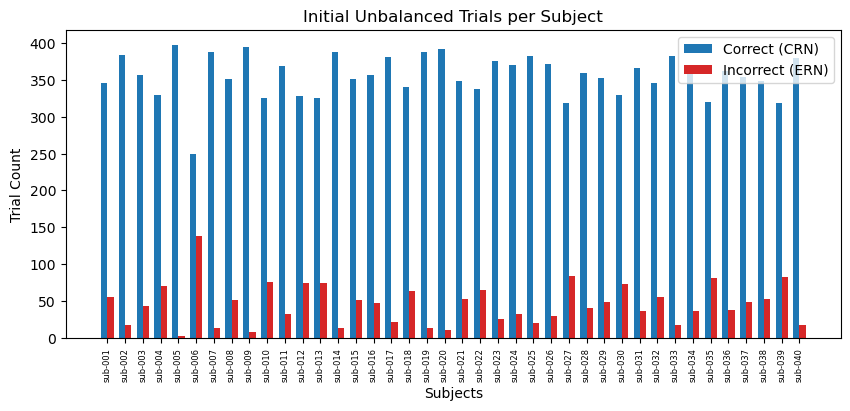

Avg. Correct Trials: 	 355.7
Avg. Incorrect Trials:	 45.4


In [3]:
report = pd.read_csv(MASTER_PREP_REPORT) if MASTER_PREP_REPORT.exists() else None

if report is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(report))
    width = 0.35
    ax.bar(x - width/2, report["correct"], width, label="Correct (CRN)", color="#1f77b4")
    ax.bar(x + width/2, report["incorrect"], width, label="Incorrect (ERN)", color="#d62728")
    ax.set_xlabel("Subjects")
    ax.set_ylabel("Trial Count")
    ax.set_title("Initial Unbalanced Trials per Subject")
    ax.set_xticks(x)
    ax.set_xticklabels(report["sub"], rotation=90, fontsize=6)
    ax.legend()
    plt.show()
    
    print(f"Avg. Correct Trials: \t {report['correct'].mean():.1f}")
    print(f"Avg. Incorrect Trials:\t {report['incorrect'].mean():.1f}")
else:
    print("Master Prep Report CSV not found.")

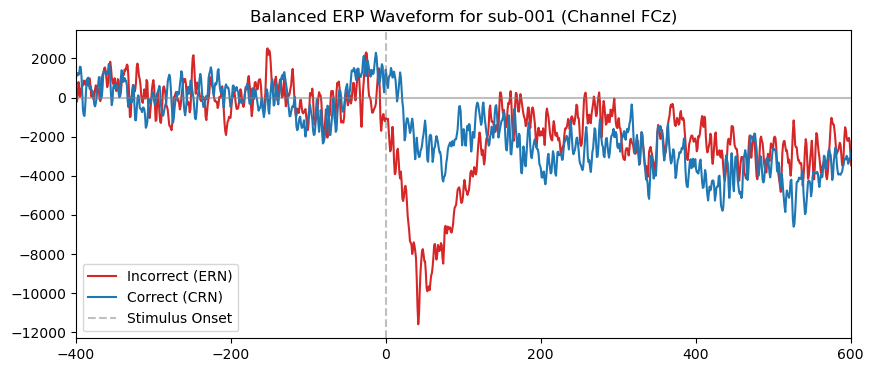

In [4]:
# Plot Dynamic Waveform Viewer for the first available Subject (FCz channel)
subjects = sorted([f.name.split("_")[0] for f in BALANCED_EPOCHS_DIR.glob("sub-*_theta_balanced-epo.fif")]) if BALANCED_EPOCHS_DIR.exists() else []

if subjects:
    target_sub = subjects[0]
    target_ch = "FCz" if "FCz" in channel_names else channel_names[0]
    
    fif_file = BALANCED_EPOCHS_DIR / f"{target_sub}_theta_balanced-epo.fif"
    epochs = mne.read_epochs(fif_file, preload=True, verbose=False)
    ch_idx = epochs.ch_names.index(target_ch)
    times_ms = epochs.times * 1000.0
    
    cw = epochs["Correct"].get_data(verbose=False)[:, ch_idx, :].mean(axis=0)
    iw = epochs["Incorrect"].get_data(verbose=False)[:, ch_idx, :].mean(axis=0)
    
    baseline_mask = (times_ms >= -200.0) & (times_ms <= 0.0)
    if baseline_mask.any():
        cw -= np.mean(cw[baseline_mask])
        iw -= np.mean(iw[baseline_mask])
    cw, iw = cw * 1e6, iw * 1e6
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(times_ms, iw, label="Incorrect (ERN)", color="#d62728", linewidth=1.5)
    ax.plot(times_ms, cw, label="Correct (CRN)", color="#1f77b4", linewidth=1.5)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5, label="Stimulus Onset")
    ax.axhline(0, color="gray", alpha=0.5)
    ax.set_xlim(-400, 600)
    ax.set_title(f"Balanced ERP Waveform for {target_sub} (Channel {target_ch})")
    ax.legend()
    plt.show()
else:
    print("No processed epochs found. Cannot plot ERP.")

## Step 3: Phase Locking Value (PLV) Tensors

Phase locking captures theta synchronization across all pairs of brain regions over time.

Loaded 4D Incorrect Cond Tensor: (40, 30, 30, 2049)


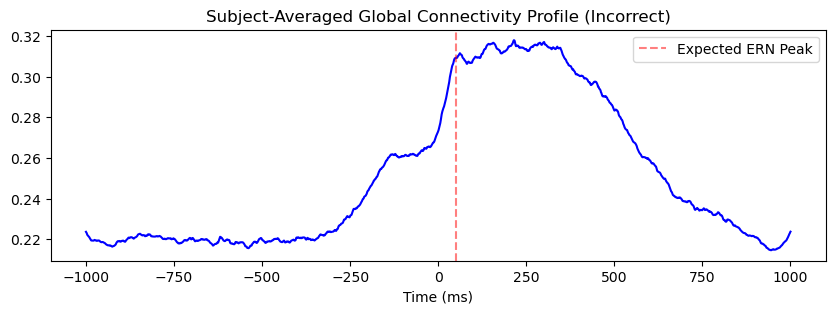

In [5]:
if TENSOR_INCORRECT.exists():
    tensor_inc = np.load(TENSOR_INCORRECT, mmap_mode="r")
    print("Loaded 4D Incorrect Cond Tensor:", tensor_inc.shape)
    
    times_plv = np.linspace(-1000.0, 1000.0, tensor_inc.shape[-1])
    global_mean = tensor_inc.mean(axis=(0, 1, 2))
    
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(times_plv, global_mean, color="blue")
    ax.axvline(50, color="red", linestyle="--", alpha=0.5, label="Expected ERN Peak")
    ax.set_title("Subject-Averaged Global Connectivity Profile (Incorrect)")
    ax.set_xlabel("Time (ms)")
    ax.legend()
    plt.show()
else:
    print("TENSOR_INCORRECT file not found.")
    times_plv = np.linspace(-1000.0, 1000.0, 2049)  # placeholder

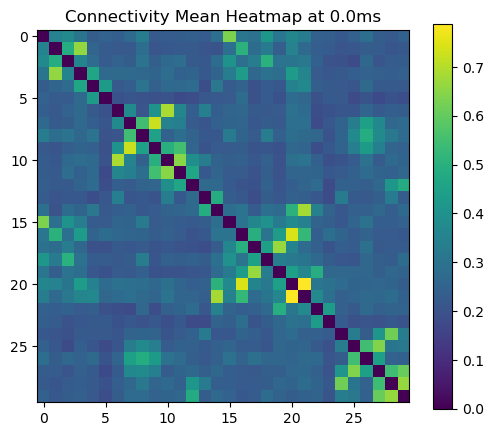

In [6]:
# Example of Connectivity Adjacency Heatmap at Center Timestamp
if 'tensor_inc' in locals():
    t_idx = len(times_plv) // 2   # approximate 0ms
    A_mean = tensor_inc[:, :, :, t_idx].mean(axis=0)
    
    def sanitize_adjacency(A):
        A = np.asarray(A, dtype=float).copy()
        A[~np.isfinite(A)] = 0
        A = (A + A.T) / 2
        A[A < 0] = 0
        np.fill_diagonal(A, 0)
        return A

    A_san = sanitize_adjacency(A_mean)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(A_san, cmap="viridis")
    ax.set_title(f"Connectivity Mean Heatmap at {times_plv[t_idx]:.1f}ms")
    fig.colorbar(im)
    plt.show()

## Step 4: HO-RLSL Low-Rank Extraction

Decomposes the PLV tensor into optimal dynamic subspace representation to remove noise.

Loaded HO-RLSL results: ['low_rank', 'sparse', 'change_points', 'raw_change_points', 'filtered_change_points', 'change_point_ms', 'change_point_modes', 'change_scores', 'change_score_times', 'change_point_score_components', 'sparse_solver', 'solver_params', 'update_times', 'rank_history', 'change_history', 'input_layout', 'output_layout', 'internal_layout', 'original_shape', 'internal_shape', 'initial_ranks', 'initial_thresholds', 'config']


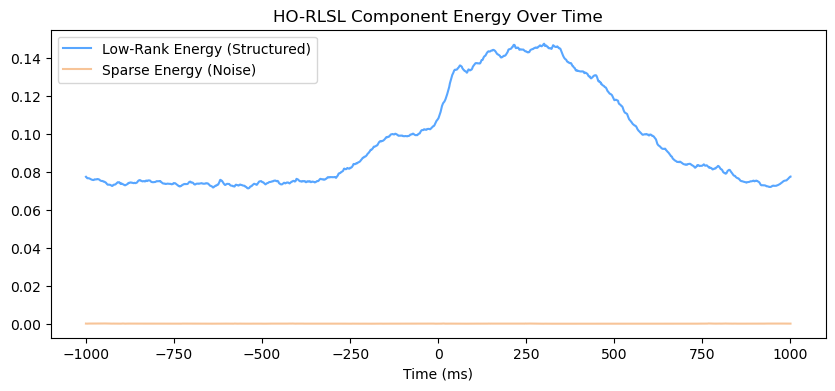

In [7]:
if HO_RLSL_RESULTS_FILE.exists():
    ho_rlsl = np.load(HO_RLSL_RESULTS_FILE)
    print("Loaded HO-RLSL results:", ho_rlsl.files)
    low_rank = ho_rlsl["low_rank"]
    sparse = ho_rlsl["sparse"]
    
    ho_times = np.linspace(-1000.0, 1000.0, low_rank.shape[-1])
    en_lr = np.mean(low_rank**2, axis=(0,1,2))
    en_sp = np.mean(sparse**2, axis=(0,1,2))
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ho_times, en_lr, color="#58a6ff", label="Low-Rank Energy (Structured)")
    ax.plot(ho_times, en_sp, color="#f08b33", alpha=0.5, label="Sparse Energy (Noise)")
    ax.set_title("HO-RLSL Component Energy Over Time")
    ax.set_xlabel("Time (ms)")
    ax.legend()
    plt.show()
else:
    print("HO-RLSL results file not found.")

## Step 5: Change Points & FCCA splits

FCCA calculates community structures at various detected state segments.

In [8]:
if HORLSL_CP_FILE.exists() and PRECOMPUTED_FCCA_FILE.exists():
    cp_data = np.load(HORLSL_CP_FILE, allow_pickle=True).item()
    cp_frames = cp_data.get("1024Hz_ERN", [])
    
    fcca_all = np.load(PRECOMPUTED_FCCA_FILE, allow_pickle=True)
    
    if 'cp_frames' in locals() and len(cp_frames) >= 2:
        start_cp = cp_frames[0]
        end_cp = cp_frames[1]
        print(f"Interval Analyzed: TS {start_cp} to {end_cp}")
        
        # Check available matrices and labels assuming FCCA output aligns by frame intervals or overall precomputed blocks
        # We simulate the display using FCCA outputs logic
        if '1024Hz_ERN_HO_RLSL' in fcca_all.files:
            run_fcca = fcca_all['1024Hz_ERN_HO_RLSL'].item()
            if len(run_fcca) > 0:
                res = run_fcca[0]  # Take first interval
                labels = res.get('labels', np.ones(n_nodes))
                k = res.get('best_k', 0)
                print(f"Found FCCA Split into {k} communities.")
                
                # Render Head Plot Outline
                fig, ax = plt.subplots(figsize=(5, 5))
                ax.scatter(xy[:, 0], xy[:, 1], c=labels, cmap='tab10', s=100)
                ax.set_title("Consensus FCCA Communities")
                ax.axis('off')
                plt.show()
else:
    print("Dependencies to visualize FCCA distributions are not fully built.")

Interval Analyzed: TS -761.71875 to -38.0859375
